In [17]:
import pandas as pd

In [46]:
df=pd.read_csv('datasets/respiratory symptoms and treatment.csv')

In [48]:
df['Symptoms'].value_counts()

Symptoms
shortness of breath                1517
Wheezing                           1360
chest pain                         1200
mucus                              1152
yellow cough                       1118
Fatigue                            1008
chronic cough                       864
cold                                845
Low-grade fever                     685
Nausea                              672
Feeling run-down or tired           624
whistling sound while breathing     538
Runny nose                          535
stuffy nose                         489
Chest congestion                    440
wheezing                            434
sweating                            336
shallow breathing                   336
shaking                             336
fatigue                             336
Loss of appetite                    336
vomiting                            336
Rapid breathing                     336
 low energy                         336
greenish cough                 

In [49]:
df['Symptoms'].unique()

array([' coughing ', 'tight feeling in the chest', ' wheezing',
       ' shortness of breath', 'shortness of breath', ' coughing',
       'coughing', 'fever', 'cold', 'wheezing', 'allergy', 'Runny nose',
       'stuffy nose', 'Low-grade fever', 'Chest congestion', 'Wheezing',
       'whistling sound while breathing', 'yellow cough',
       'Feeling run-down or tired', 'mucus', 'chest pain',
       'chronic cough', 'Fatigue', nan, 'greenish cough',
       'cough with blood', 'Fever', 'sweating', 'shaking',
       'Rapid breathing', 'shallow breathing', ' low energy',
       'Loss of appetite', 'fatigue', 'Nausea', 'vomiting'], dtype=object)

In [52]:
df['Symptoms']=df['Symptoms'].str.strip()

In [58]:
len(df['Symptoms'].value_counts())

31

In [26]:
import seaborn as sns

<Axes: xlabel='Symptoms', ylabel='Count'>

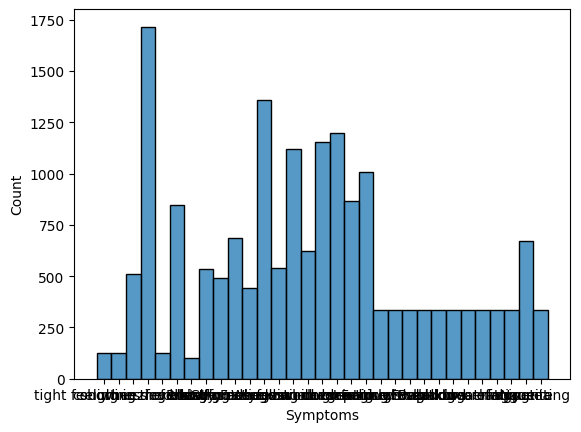

In [60]:
sns.histplot(df['Symptoms'])

In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras import layers, models

In [32]:
# 1. Load and Basic Cleaning
df = pd.read_csv('datasets/respiratory symptoms and treatment.csv')
df = df.drop(columns=['Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8']) # Drop empty columns
df['Disease'] = df['Disease'].str.lower().str.strip()

In [33]:
# 2. Fill Missing Values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Sex'] = df['Sex'].fillna('unknown')
df['Symptoms'] = df['Symptoms'].fillna('unknown')


In [34]:
df_features = pd.get_dummies(df[['Age', 'Sex', 'Symptoms']], drop_first=True)


In [35]:
# Label encode target
le = LabelEncoder()
y = le.fit_transform(df['Disease'])
num_classes = len(le.classes_)

In [38]:
# 4. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(df_features, y, test_size=0.2, random_state=42)

In [39]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [41]:
# 5. Build the ANN
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2), # Prevents overfitting
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax') # Multi-class output
])

In [42]:
ZZZmodel.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [45]:
history = model.fit(X_train, y_train, epochs=60, batch_size=32, validation_split=0.1)


Epoch 1/60
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8983 - loss: 0.2171 - val_accuracy: 0.9205 - val_loss: 0.1858
Epoch 2/60
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8988 - loss: 0.2151 - val_accuracy: 0.9053 - val_loss: 0.1892
Epoch 3/60
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8979 - loss: 0.2146 - val_accuracy: 0.9108 - val_loss: 0.1878
Epoch 4/60
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8998 - loss: 0.2134 - val_accuracy: 0.9073 - val_loss: 0.1813
Epoch 5/60
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8988 - loss: 0.2113 - val_accuracy: 0.9115 - val_loss: 0.1860
Epoch 6/60
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8999 - loss: 0.2111 - val_accuracy: 0.9087 - val_loss: 0.1773
Epoch 7/60
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8996 - loss: 0.2099 - val_accuracy: 0.9073 - val_loss: 0.1801
Epoch 8/60
407/407 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8998 - loss: 0.2079 - val_accuracy: 0.

In [44]:
# 7. Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.2f}")

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9051 - loss: 0.1992  
Test Accuracy: 0.91
